# Goldpreisprognose nach CRISP-DM

Dieses Notebook orchestriert ausschließlich Funktionen aus dem installierbaren Paket (`src/gold_forecasting`). Jedes Modell besitzt eine eigene Datei unter `src/gold_forecasting/models/`; das Notebook ruft pro Modell genau eine Funktion auf und enthält selbst keine Modell-, Trainings- oder Feature-Logik. Alle Abbildungen werden als PNG gespeichert und anschließend von der Festplatte angezeigt.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from gold_forecasting.config import load_yaml, select_device, set_seed
from gold_forecasting.data_download import download_all
from gold_forecasting.data_preparation import prepare_dataset
from gold_forecasting.splitting import chronological_split
from gold_forecasting.plotting import plot_history, plot_chronological_split
from gold_forecasting.experiments import run_baselines, compare_results, run_future

from gold_forecasting.models.sarima import run_sarima, SarimaForecaster
from gold_forecasting.models.patchtst import run_patchtst, PatchTSTForecaster
from gold_forecasting.models.chronos_zero_shot import run_chronos_original, run_chronos_bolt, ChronosForecaster
from gold_forecasting.models.sarimax import run_sarimax
from gold_forecasting.models.xgboost_model import run_xgboost
from gold_forecasting.models.tft import run_tft

## 1. Geschäftsverständnis

Ziel ist die Prognose des täglichen Goldpreises in USD je Feinunze. Die Prognosen unterstützen eine methodische Bewertung, sind aber keine Anlageberatung. Finanzmärkte reagieren auf Regimewechsel, Liquidität und unerwartete Ereignisse; deshalb bleiben selbst gute historische Ergebnisse unsicher. Ein Mehrwert gegenüber der naiven Persistenz und dem gleitenden Durchschnitt ist entscheidend, weil komplexe Modelle sonst keinen belegbaren Zusatznutzen liefern.

Zwei Experimente werden verglichen:

- **Experiment 1 (univariat):** SARIMA, PatchTST und Chronos (Original & Bolt, Zero-Shot) prognostizieren allein aus der Goldpreis-Historie.
- **Experiment 2 (multivariat):** SARIMAX, XGBoost und ein kompaktes, nativ implementiertes TFT nutzen zusätzlich die exogenen Reihen aus `configs/data.yaml`.

## 2. Datenverständnis

Yahoo Finance liefert Gold-Futures (`GC=F`) sowie optionale Reihen für US-Dollar-Index, Silber, Öl, S&P 500, VIX und Bitcoin. Unterschiedliche Handelskalender erzeugen Lücken. Der Goldpreis wird niemals über Nicht-Handelstage fortgeschrieben; exogene Reihen werden höchstens drei Ziel-Handelstage und ausschließlich aus der Vergangenheit fortgeschrieben. Das Enddatum der heruntergeladenen Daten (`configs/data.yaml: end`) ist konfigurierbar und aktuell auf den 30. Juni 2026 gesetzt.

,gold_usd,dollar_index,silver,oil,sp500,vix,bitcoin
count,6488.000000,6488.000000,6488.000000,6488.000000,6488.000000,6488.000000,2969.000000
mean,1319.869111,92.604918,19.153107,65.042719,2389.797609,19.756117,28934.027273
std,866.655368,11.096726,12.770116,24.568320,1601.670848,8.382655,32495.904342
min,255.100006,71.330002,4.026000,-37.630001,676.530029,9.140000,178.102997
25%,656.700012,82.639999,12.358750,46.765000,1210.109985,13.980000,3486.950195
50%,1255.350037,93.269997,17.091000,64.080002,1680.549988,17.615001,11774.595703
75%,1713.950012,99.570000,23.914999,82.550003,3031.329956,23.022501,47128.003906
max,5318.399902,120.900002,115.080002,145.289993,7609.779785,82.690002,124752.531250


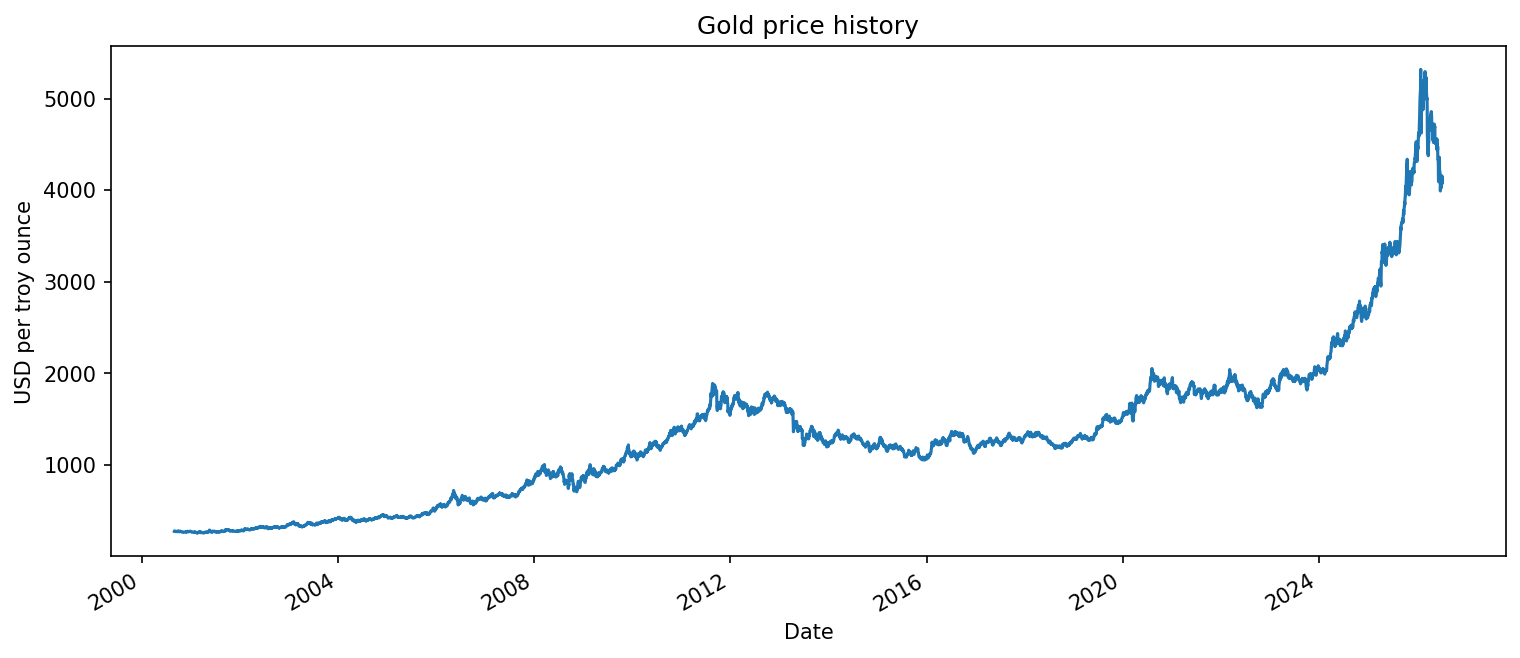

In [2]:
data_config = load_yaml('data.yaml')
raw_paths = download_all(data_config, force_download=False)
exogenous_names = list(data_config['exogenous'])
data, data_hash = prepare_dataset(raw_paths[0], dict(zip(exogenous_names, raw_paths[1:])))
display(data.describe())
display(Image(filename=str(plot_history(data['gold_usd'], data_hash))))

**Interpretation:** Die Zeitreihe zeigt Preisniveau, Schwankungsbreite und Datenabdeckung. Korrelationen sind deskriptiv und begründen keine Kausalität.

## 3. Datenvorbereitung

Die Hauptanalyse prognostiziert Preisniveaus. Skalierer werden ausschließlich auf Trainingsdaten angepasst (pro Modell dokumentiert in Kapitel 4). Zielbasierte Lags und rollierende Kennzahlen verwenden nur verschobene Vergangenheitswerte; zentrierte Fenster sind ausgeschlossen.

**Konfigurierbarer, chronologischer Split:** Validierung und Test sind je `split.validation_years`/`split.test_years` Jahre lang (aktuell 2.5 Jahre) und werden rückwärts vom letzten verfügbaren Datum abgeschnitten; alles davor wird zu Training. Diese Werte -- ebenso wie das Enddatum der Daten (`data.yaml: end`) -- sind vollständig in den YAML-Konfigurationsdateien einstellbar, ohne Code zu ändern. Test bleibt während der gesamten Modellierung strikt verborgen; Validierung dient ausschließlich der Hyperparameteroptimierung und dem Early Stopping.

mode=full_mode  hpo_trials=25  epochs=60  seed=42
split: validation=2.5y  test=2.5y
train=2000-08-30..2021-07-09 (5231 rows)
validation=2021-07-12..2024-01-10 (630 rows)
test=2024-01-11..2026-07-10 (627 rows)


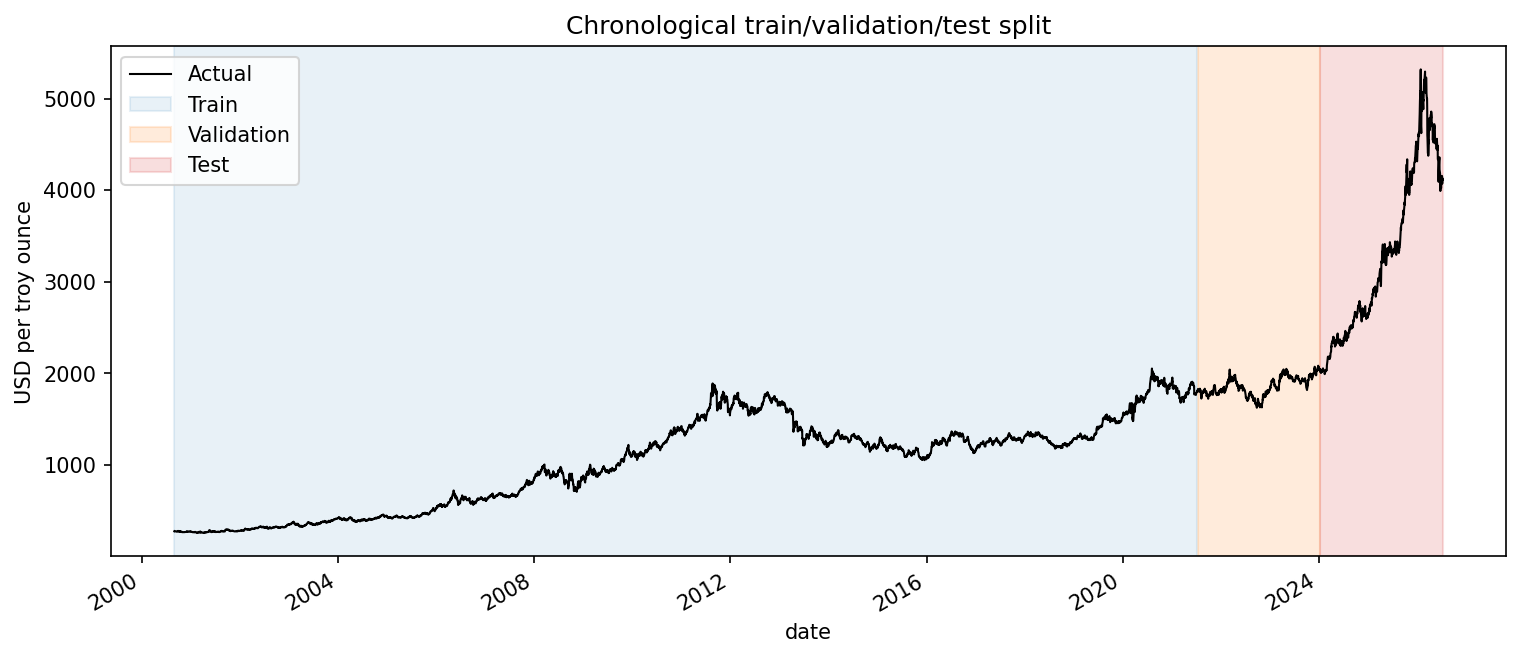

In [3]:
experiment_config = load_yaml('experiments.yaml')
models_config = load_yaml('models.yaml')
mode = experiment_config['mode']
hpo = models_config['hpo'][mode]
seed = int(models_config['seed'])
set_seed(seed)
device = select_device()
evaluation_horizons = experiment_config['evaluation_horizons']

# Univariate split (Experiment 1): target only.
split_uni = chronological_split(data[['gold_usd']], **experiment_config['split'])
# Multivariate split (Experiment 2): target + exogenous columns, same boundaries.
multivariate_columns = ['gold_usd', *exogenous_names]
split_multi = chronological_split(data[multivariate_columns].dropna(), **experiment_config['split'])

print(f"mode={mode}  hpo_trials={hpo['n_trials']}  epochs={hpo['epochs']}  seed={seed}")
print(f"split: validation={experiment_config['split']['validation_years']}y  test={experiment_config['split']['test_years']}y")
print(f"train={split_uni.train.index.min().date()}..{split_uni.train.index.max().date()} ({len(split_uni.train)} rows)")
print(f"validation={split_uni.validation.index.min().date()}..{split_uni.validation.index.max().date()} ({len(split_uni.validation)} rows)")
print(f"test={split_uni.test.index.min().date()}..{split_uni.test.index.max().date()} ({len(split_uni.test)} rows)")
display(Image(filename=str(plot_chronological_split(data['gold_usd'], split_uni, data_hash))))

## 4. Modellierung

Verglichen werden zwei Experimente. Alle Modelle sind entweder nativ in PyTorch implementiert (PatchTST, TFT) oder verwenden etablierte Bibliotheken (statsmodels, XGBoost, Chronos). Hyperparameteroptimierung läuft über Optuna-Studien, die in `artifacts/optuna/*.db` gespeichert werden: wird ein Lauf unterbrochen, führt der nächste Aufruf nur die noch fehlenden Trials aus, statt neu zu beginnen. Ergebnisse (Vorhersagen, Metriken, Checkpoints) sind inhaltsadressiert zwischengespeichert -- ein unveränderter Aufruf liest aus dem Cache statt neu zu trainieren.

### 4.1 Experiment 1: Univariate Prognose (ohne exogene Variablen)

- **SARIMA:** Optuna durchsucht (p, d, q) auf Basis des Validierungsfehlers; keine Skalierung nötig, da statsmodels direkt auf USD-Preisen arbeitet.
- **PatchTST:** Architektur- und Optimierungs-Hyperparameter werden per Optuna gesucht; die Zielreihe wird mit einem ausschließlich auf Trainingsdaten angepassten `StandardScaler` skaliert.
- **Chronos (Original & Bolt):** vortrainierte Zero-Shot-Modelle von Amazon -- kein Training, keine Hyperparameteroptimierung. Chronos normalisiert seinen Eingabekontext intern; keine externe Skalierung nötig.

Die finale Testprognose wird rekursiv ab dem Ende von Training+Validierung erzeugt (echter "frozen-origin"-Mehrschritt-Forecast); zu keinem Zeitpunkt fließen reale Testwerte in die Eingabe ein.

In [4]:
sarima_result = run_sarima(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                            models_config['sarima'], hpo, data_hash, seed, evaluation_horizons=evaluation_horizons)
print('SARIMA best params:', sarima_result['best_params'])

D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA best params: {'order': [1, 2, 3], 'seasonal_order': [0, 0, 0, 0]}


In [5]:
patchtst_result = run_patchtst(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                models_config['patchtst'], hpo, data_hash, seed, evaluation_horizons=evaluation_horizons)
print('PatchTST best params:', patchtst_result['best_params'])

PatchTST best params: {'context_length': 64, 'nhead': 8, 'd_model': 48, 'patch_length': 9, 'stride': 5, 'layers': 2, 'learning_rate': 0.0007212001405714604, 'batch_size': 32, 'epochs': 60, 'patience': 8}


In [6]:
chronos_original_result = run_chronos_original(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                                models_config['chronos'], data_hash, seed, evaluation_horizons=evaluation_horizons)
chronos_bolt_result = run_chronos_bolt(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                        models_config['chronos'], data_hash, seed, evaluation_horizons=evaluation_horizons)

In [7]:
univariate_baselines = run_baselines(split_uni.train.gold_usd, split_uni.validation.gold_usd, split_uni.test.gold_usd,
                                      'univariate', data_hash, seed, {'evaluation_horizons': evaluation_horizons},
                                      moving_average_window=experiment_config['moving_average_window'])

,model,horizon,mae,rmse,mase,smape,directional_accuracy
10,chronos_original,1,3.667987,3.667987,0.458973,0.181932,NaN
20,naive,1,7.399902,7.399902,0.925946,0.366695,NaN
15,chronos_bolt,1,7.490194,7.490194,0.937244,0.371161,NaN
0,sarima,1,7.958465,7.958465,0.995839,0.394319,NaN
5,patchtst,1,19.728394,19.728394,2.468604,0.984237,NaN
25,moving_average,1,216.000037,216.000037,27.027977,11.330852,NaN
11,chronos_original,7,9.230588,14.048233,1.155019,0.456281,1.000000
21,naive,7,9.371408,12.531777,1.172640,0.463142,1.000000
1,sarima,7,9.692077,12.707145,1.212765,0.478995,1.000000
16,chronos_bolt,7,11.710205,13.336091,1.465292,0.579191,0.833333


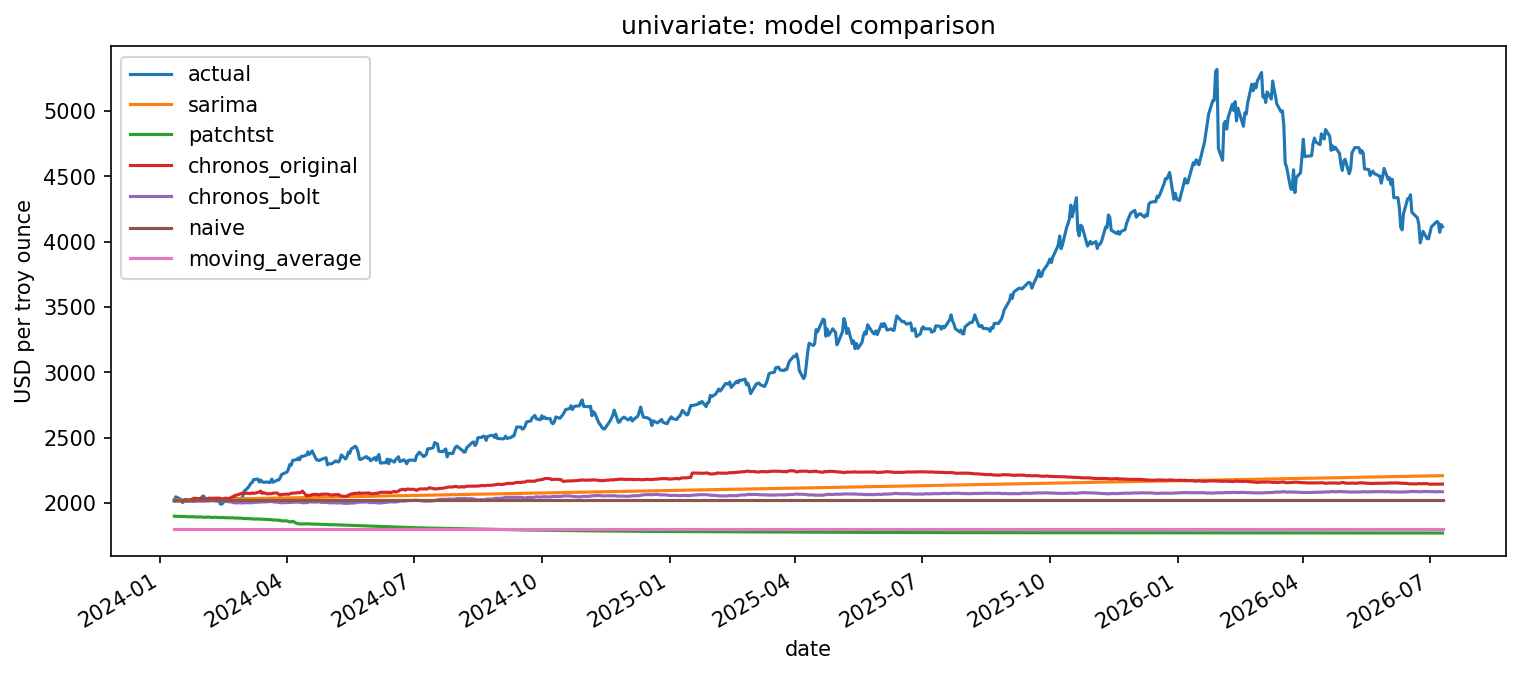

In [8]:
univariate_results = {
    'sarima': sarima_result, 'patchtst': patchtst_result,
    'chronos_original': chronos_original_result, 'chronos_bolt': chronos_bolt_result,
    **univariate_baselines,
}
univariate_metrics, univariate_plot = compare_results(univariate_results, 'univariate', data_hash)
display(univariate_metrics)
display(Image(filename=str(univariate_plot)))

### 4.2 Experiment 2: Multivariate Prognose (mit exogenen Variablen)

Exogene Variablen stammen aus `configs/data.yaml: exogenous` (US-Dollar-Index, Silber, Öl, S&P 500, VIX, Bitcoin).

- **SARIMAX:** Optuna durchsucht (p, d, q); exogene Regressoren werden mit einem ausschließlich auf Trainingsdaten angepassten `StandardScaler` skaliert (Konditionierung der Koeffizienten), die Zielgröße bleibt unskaliert.
- **XGBoost:** Lag-, Rolling- und exogene Features (`feature_engineering.create_features`); keine Skalierung nötig, da baumbasierte Modelle skaleninvariant sind. Hyperparameter werden per Optuna gesucht.
- **TFT (kompakt, nativ):** Variable-Selection-Gating, LSTM-Encoder und ein Multi-Head-Attention-Block -- eine schlanke, nativ in PyTorch implementierte Annäherung an den Temporal Fusion Transformer. Alle Kanäle werden gemeinsam mit einem trainingsbasierten `StandardScaler` skaliert.

**Wichtige Annahme:** Die Mehrschritt-Testprognose dieser drei Modelle verwendet die tatsächlich realisierten exogenen Werte des Testzeitraums (ein Standard-Backtesting-Verhalten für Modelle mit exogenen Regressoren), während die Ziel-Lags weiterhin ausschließlich rekursiv aus den eigenen Vorhersagen gebildet werden -- reale zukünftige Goldpreise fließen nie ein. Für eine echte Zukunftsprognose (unbekannte künftige exogene Werte) siehe Kapitel 6, das auf Experiment 1 beschränkt bleibt.

In [9]:
sarimax_result = run_sarimax(split_multi.train, split_multi.validation, split_multi.test,
                              models_config['sarimax'], hpo, data_hash, seed, evaluation_horizons=evaluation_horizons)
print('SARIMAX best params:', sarimax_result['best_params'])

D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Master\Projects\AI_for_Business_Prognosis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX best params: {'order': [3, 2, 3], 'seasonal_order': [0, 0, 0, 0]}


In [10]:
xgboost_result = run_xgboost(split_multi.train, split_multi.validation, split_multi.test,
                              models_config['xgboost'], hpo, data_config['features'], data_hash, seed, evaluation_horizons=evaluation_horizons)
print('XGBoost best params:', xgboost_result['best_params'])

XGBoost best params: {'max_depth': 3, 'learning_rate': 0.031727693102218096, 'n_estimators': 225, 'subsample': 0.9188465622467761, 'colsample_bytree': 0.9224680278761717}


In [11]:
tft_result = run_tft(split_multi.train, split_multi.validation, split_multi.test,
                      models_config['tft'], hpo, data_hash, seed, evaluation_horizons=evaluation_horizons)

In [12]:
multivariate_baselines = run_baselines(split_multi.train.gold_usd, split_multi.validation.gold_usd, split_multi.test.gold_usd,
                                        'multivariate', data_hash, seed, {'evaluation_horizons': evaluation_horizons},
                                        moving_average_window=experiment_config['moving_average_window'])

,model,horizon,mae,rmse,mase,smape,directional_accuracy
5,xgboost,1,0.503174,0.503174,0.054387,0.024977,NaN
0,sarimax,1,1.606157,1.606157,0.173605,0.079770,NaN
15,naive,1,7.399902,7.399902,0.799835,0.366695,NaN
10,tft,1,53.321045,53.321045,5.763327,2.682632,NaN
20,moving_average,1,216.000037,216.000037,23.346858,11.330852,NaN
1,sarimax,7,9.068177,10.713628,0.980155,0.448812,0.833333
16,naive,7,9.371408,12.531777,1.012930,0.463142,1.000000
6,xgboost,7,11.261876,14.075624,1.217266,0.556952,0.833333
11,tft,7,85.046038,86.719762,9.192395,4.296734,0.500000
21,moving_average,7,223.771416,224.121740,24.186845,11.712621,0.500000


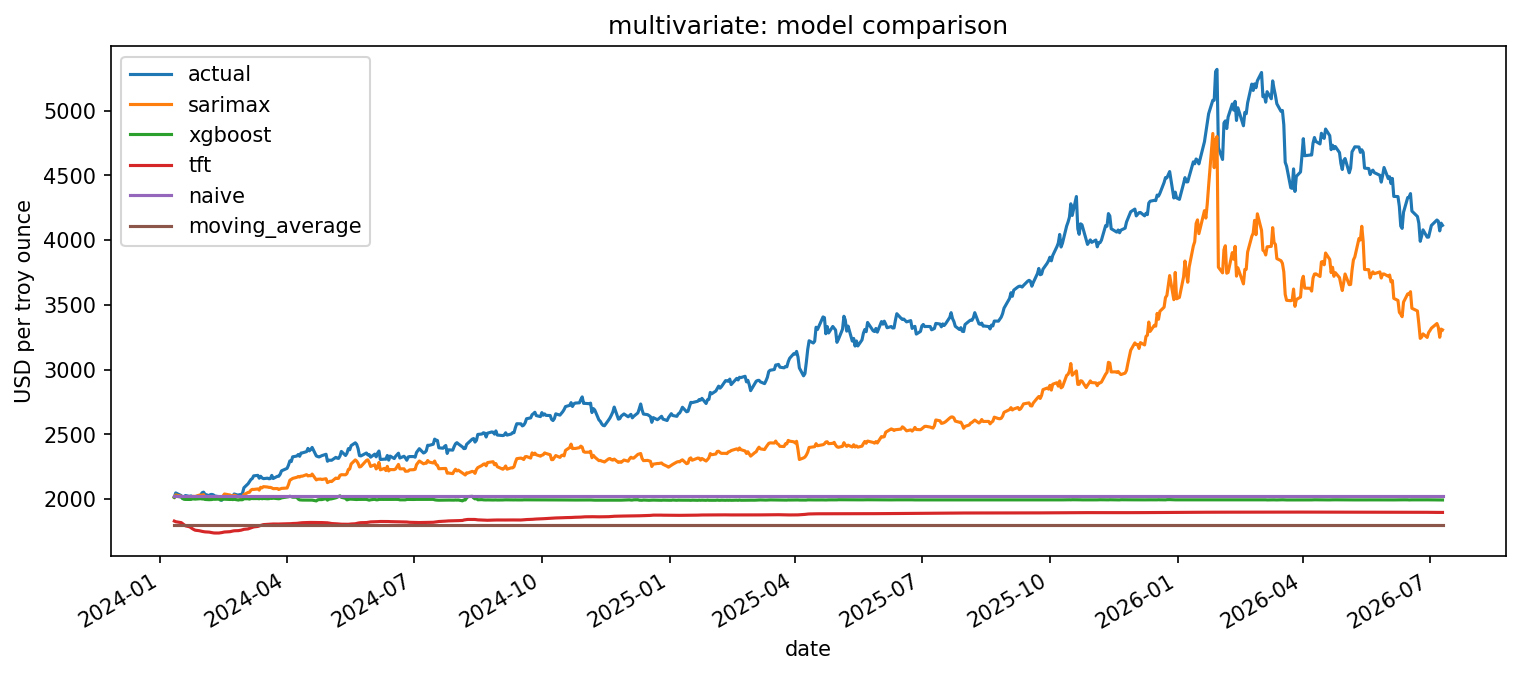

In [13]:
multivariate_results = {
    'sarimax': sarimax_result, 'xgboost': xgboost_result, 'tft': tft_result,
    **multivariate_baselines,
}
multivariate_metrics, multivariate_plot = compare_results(multivariate_results, 'multivariate', data_hash)
display(multivariate_metrics)
display(Image(filename=str(multivariate_plot)))

## 5. Evaluation

Beim strikt eingefrorenen Ursprung enden Training, Skalierung, Validierung und Modellwahl vor dem Testzeitraum (2.5 Jahre, siehe Kapitel 3). Während der gesamten maskierten Periode werden keine echten Goldpreise als neue Eingaben verwendet -- mit der in Kapitel 4.2 dokumentierten, expliziten Ausnahme der exogenen Regressoren in Experiment 2. MAE, RMSE, MASE, sMAPE und Richtungsgenauigkeit werden für 1, 7, 30, 90 Tage und den vollständigen Zeitraum berichtet. MASE unter 1 bedeutet eine Verbesserung gegenüber der skalierten naiven Ein-Schritt-Abweichung.

In [14]:
print('Experiment 1 (univariat) -- Rang nach MAE je Horizont:')
display(univariate_metrics.sort_values(['horizon', 'mae']))
print('Experiment 2 (multivariat) -- Rang nach MAE je Horizont:')
display(multivariate_metrics.sort_values(['horizon', 'mae']))

Experiment 1 (univariat) -- Rang nach MAE je Horizont:


,model,horizon,mae,rmse,mase,smape,directional_accuracy
10,chronos_original,1,3.667987,3.667987,0.458973,0.181932,NaN
20,naive,1,7.399902,7.399902,0.925946,0.366695,NaN
15,chronos_bolt,1,7.490194,7.490194,0.937244,0.371161,NaN
0,sarima,1,7.958465,7.958465,0.995839,0.394319,NaN
5,patchtst,1,19.728394,19.728394,2.468604,0.984237,NaN
25,moving_average,1,216.000037,216.000037,27.027977,11.330852,NaN
11,chronos_original,7,9.230588,14.048233,1.155019,0.456281,1.000000
21,naive,7,9.371408,12.531777,1.172640,0.463142,1.000000
1,sarima,7,9.692077,12.707145,1.212765,0.478995,1.000000
16,chronos_bolt,7,11.710205,13.336091,1.465292,0.579191,0.833333


Experiment 2 (multivariat) -- Rang nach MAE je Horizont:


,model,horizon,mae,rmse,mase,smape,directional_accuracy
5,xgboost,1,0.503174,0.503174,0.054387,0.024977,NaN
0,sarimax,1,1.606157,1.606157,0.173605,0.079770,NaN
15,naive,1,7.399902,7.399902,0.799835,0.366695,NaN
10,tft,1,53.321045,53.321045,5.763327,2.682632,NaN
20,moving_average,1,216.000037,216.000037,23.346858,11.330852,NaN
1,sarimax,7,9.068177,10.713628,0.980155,0.448812,0.833333
16,naive,7,9.371408,12.531777,1.012930,0.463142,1.000000
6,xgboost,7,11.261876,14.075624,1.217266,0.556952,0.833333
11,tft,7,85.046038,86.719762,9.192395,4.296734,0.500000
21,moving_average,7,223.771416,224.121740,24.186845,11.712621,0.500000


**Interpretation:** Niedrigere Fehler sind besser; Richtungsgenauigkeit muss im Kontext betrachtet werden. Ein komplexes Modell überzeugt nur, wenn es Naiv und gleitenden Durchschnitt robust schlägt (MASE < 1). Die einmalige Test-Periode begrenzt die Verallgemeinerbarkeit und ersetzt kein Backtesting über mehrere Marktregime.

## 6. Bereitstellung

Für eine echte Zukunftsprognose (Daten jenseits des heruntergeladenen Enddatums) werden ausschließlich die univariaten Modelle aus Experiment 1 verwendet: Für SARIMAX, XGBoost und TFT müssten die exogenen Variablen selbst prognostiziert werden, was hier bewusst außerhalb des Projektumfangs bleibt. Jedes Modell wird mit der gesamten verfügbaren Historie (Training + Validierung + Test) neu angepasst -- unter Wiederverwendung der Standardkonfiguration aus `configs/models.yaml` (`fallback`), ohne erneute Hyperparametersuche, um die Bereitstellung schnell zu halten. Zukunftsprognosen sind modellbasierte Szenarien mit erheblicher Unsicherheit und ausdrücklich keine Anlageberatung.

,sarima,patchtst,chronos_original,chronos_bolt
date,,,,
2026-07-13,4112.585748,3056.2358,4115.120715,4092.572862
2026-07-14,4114.554997,3055.4849,4103.474243,4108.091471
2026-07-15,4112.733952,3053.2576,4107.356689,4115.501872
2026-07-16,4114.209934,3052.4683,4104.768054,4114.562446
2026-07-17,4113.063478,3054.0198,4100.886096,4118.937419
2026-07-20,4113.940349,3053.6353,4106.062720,4117.540717
2026-07-21,4113.273559,3050.1318,4106.062366,4119.019396
2026-07-22,4113.779472,3049.9180,4086.651538,4122.154785
2026-07-23,4113.395949,3050.3965,4086.651538,4117.565809


<Axes: title={'center': 'Zukunftsprognose (univariate Modelle)'}, xlabel='date', ylabel='USD per troy ounce'>

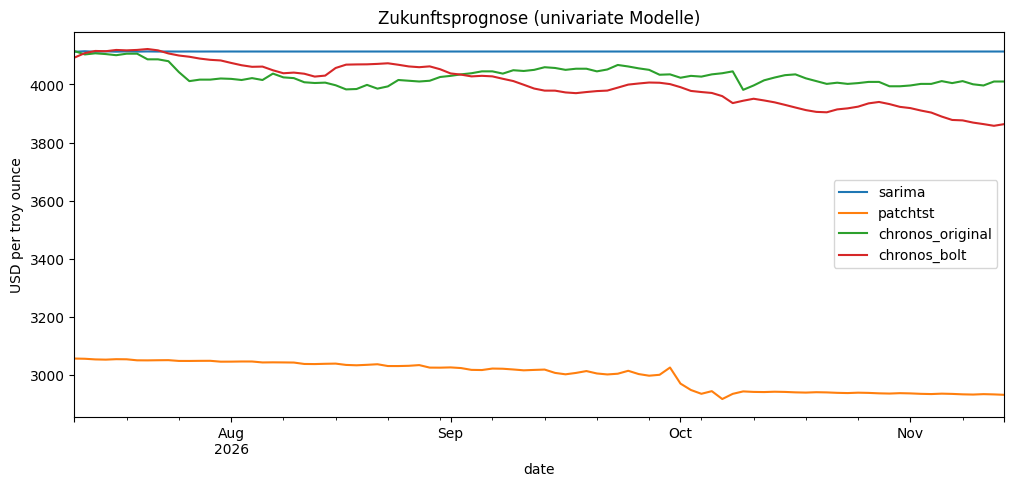

In [15]:
future_horizon = max(experiment_config['future_horizons'])
full_series = data['gold_usd'].dropna()

future_models = {
    'sarima': SarimaForecaster(config=models_config['sarima']),
    'patchtst': PatchTSTForecaster(config={'context_length': models_config['patchtst']['context_length'], **models_config['patchtst']['fallback'], 'epochs': hpo['epochs'], 'patience': hpo['patience']}, device=device, seed=seed),
    'chronos_original': ChronosForecaster(config={'model_id': models_config['chronos']['variants']['original']}, device=device),
    'chronos_bolt': ChronosForecaster(config={'model_id': models_config['chronos']['variants']['bolt']}, device=device),
}
future_forecasts = {}
for name, model in future_models.items():
    future_forecasts[name] = run_future(model, name, full_series, future_horizon, data_hash, seed, {'approach': 'univariate-future'})

future_combined = pd.concat({name: frame['predicted'] for name, frame in future_forecasts.items()}, axis=1)
display(future_combined.head(30))
future_combined.plot(figsize=(12, 5), title='Zukunftsprognose (univariate Modelle)', ylabel='USD per troy ounce')

**Interpretation:** Unterschiede zwischen Modellen verdeutlichen Modellunsicherheit. Nicht abgebildet sind verlässliche Konfidenzintervalle, Transaktionskosten, strukturelle Brüche und extreme Ereignisse. Entscheidungen dürfen nicht allein auf diesen Punktprognosen beruhen.